# Coordinate extraction for each canton

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
from pathlib import Path
from gadm import GADMDownloader

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\pycountry\__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


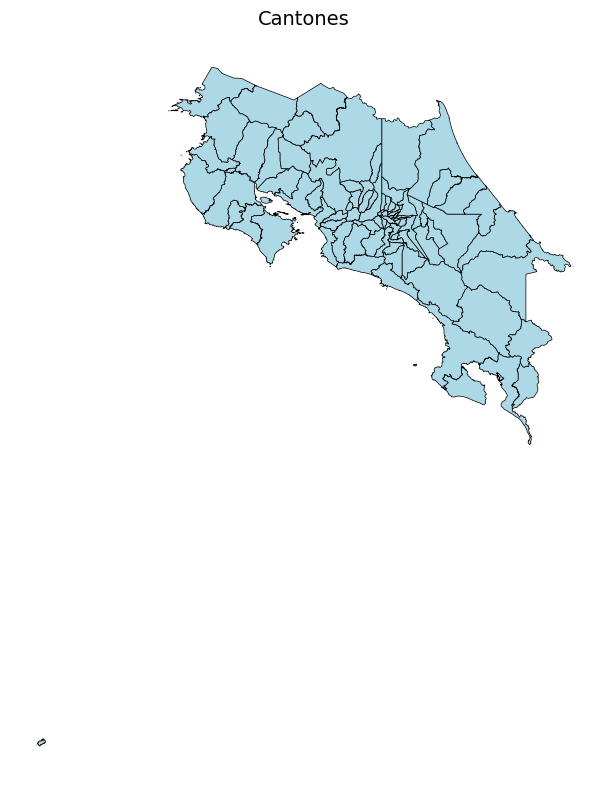

In [2]:
downloader = GADMDownloader(version="4.0")
crc = downloader.get_shape_data_by_country_name("Costa Rica", ad_level=2)

aut = crc.to_crs("EPSG:4326")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
aut.plot(ax=ax, color='lightblue', edgecolor='black', linewidth=0.5)
ax.set_title("Cantones", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [3]:
bounds = aut.total_bounds  # [minx, miny, maxx, maxy]
x = np.arange(bounds[0], bounds[2]+0.1, 0.1)  # Longitudes
y = np.arange(bounds[1], bounds[3]+0.1, 0.1)  # Latitudes
xx, yy = np.meshgrid(x, y)
bounds = aut.total_bounds

x = np.arange(bounds[0], bounds[2], 0.1)
y = np.arange(bounds[1], bounds[3], 0.1)
xx, yy = np.meshgrid(x, y)
points = [Point(lon, lat) for lon, lat in zip(xx.flatten(), yy.flatten())]
grid_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")

# Spatial join: grid points → cantons
grid = gpd.sjoin(
    grid_gdf,
    aut[['NAME_2', 'geometry']],  # keep canton name
    predicate='intersects'
).reset_index(drop=True)

# Extract lon/lat + canton
lonlat = pd.DataFrame({
    'lon': grid.geometry.x,
    'lat': grid.geometry.y,
    'canton': grid['NAME_2']
})


In [4]:
lonlat.to_csv('../data/raw/locations.csv', index=False)